Loaded EEG segment shape: (106944, 32)
Using channel pair: Fp1, Fp2
Main rotation angle: 45.00 deg


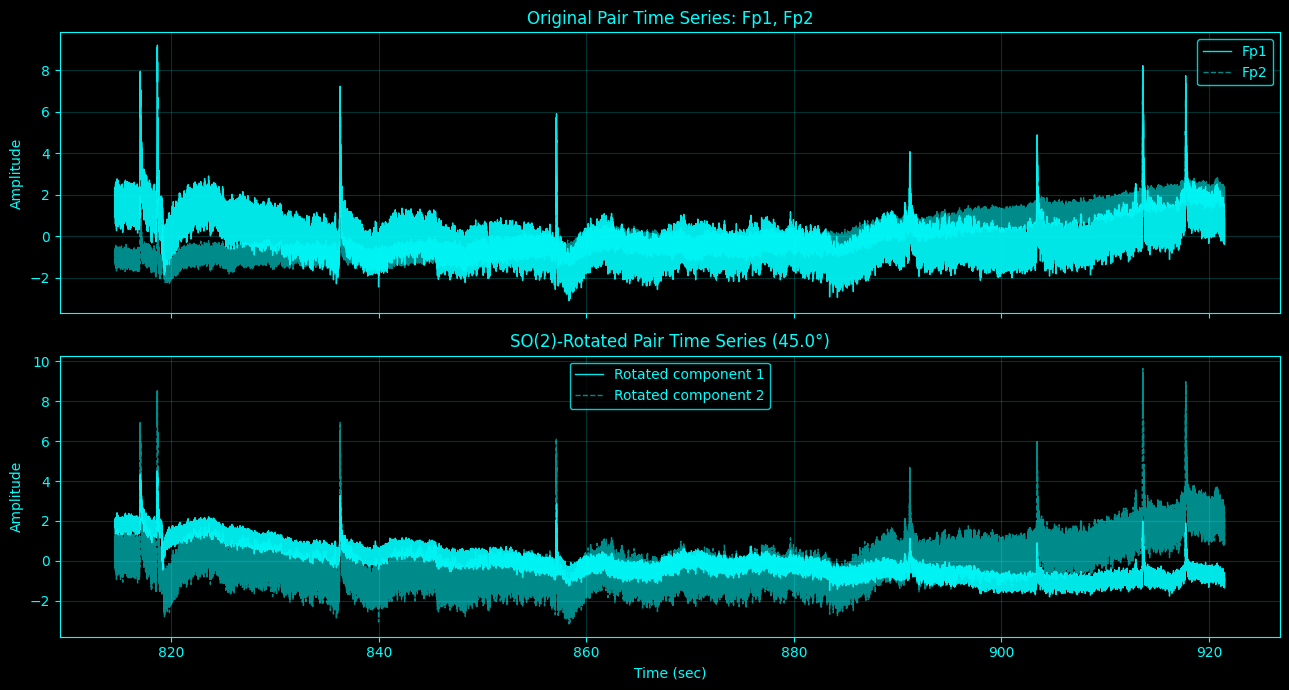

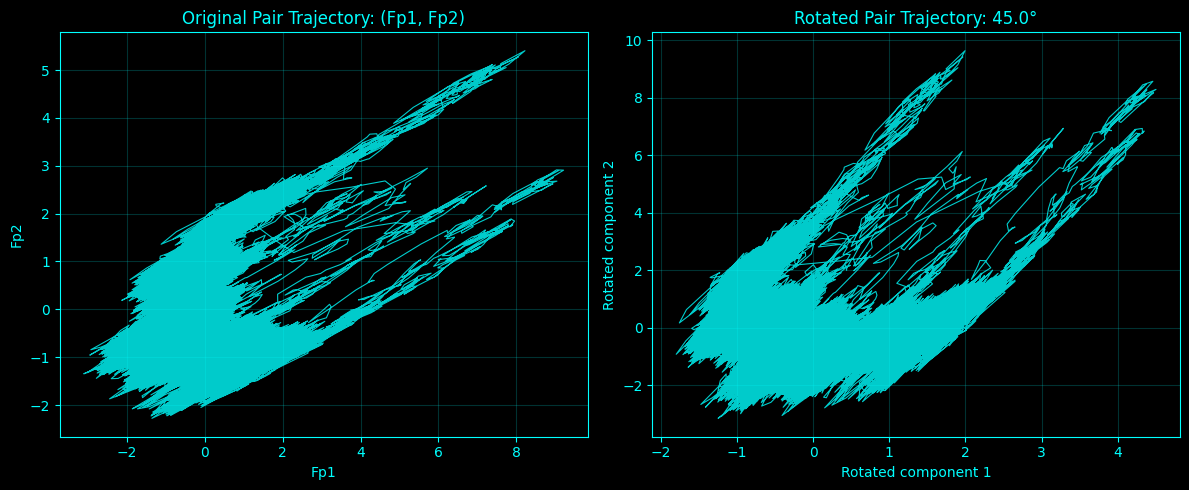

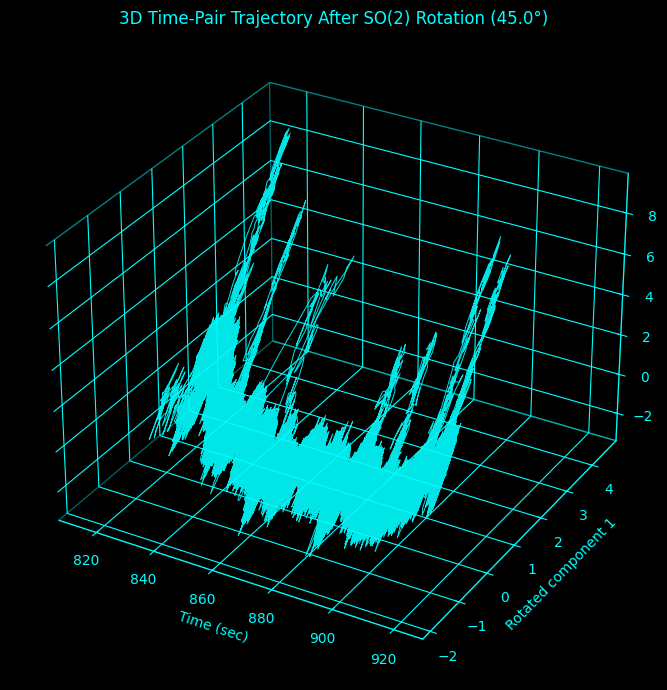

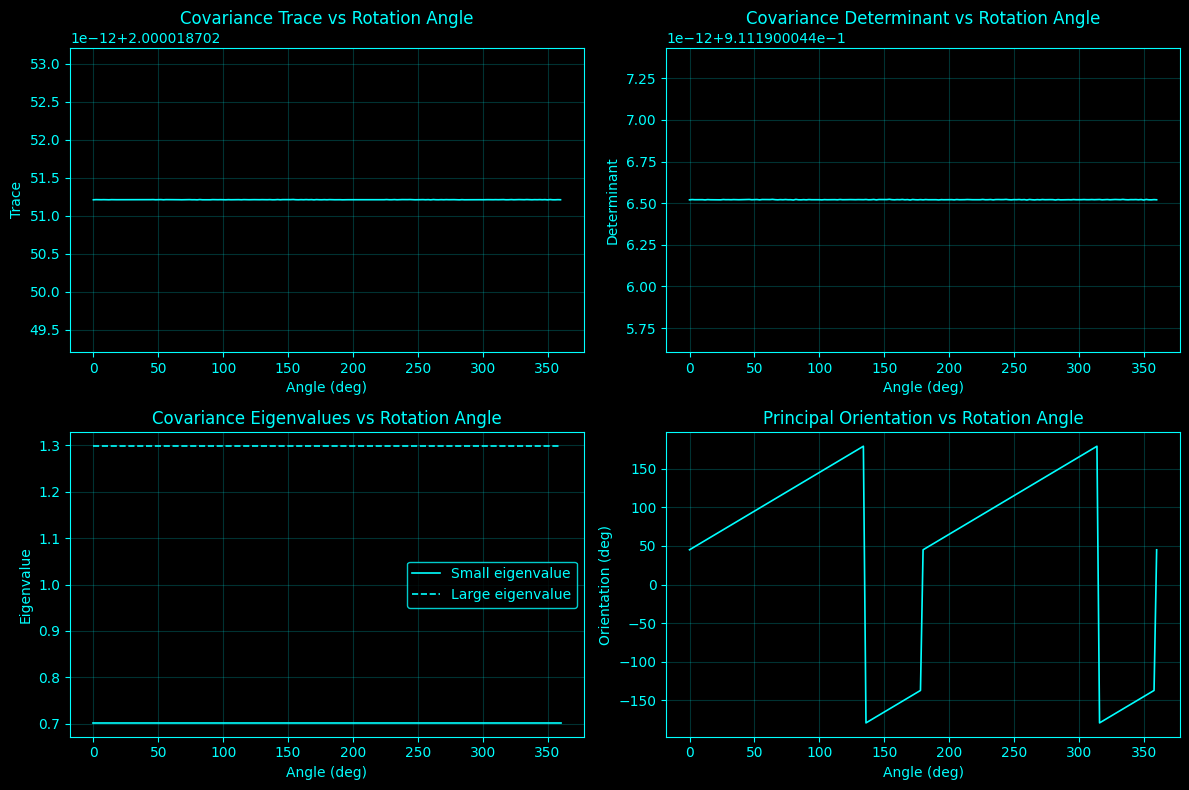

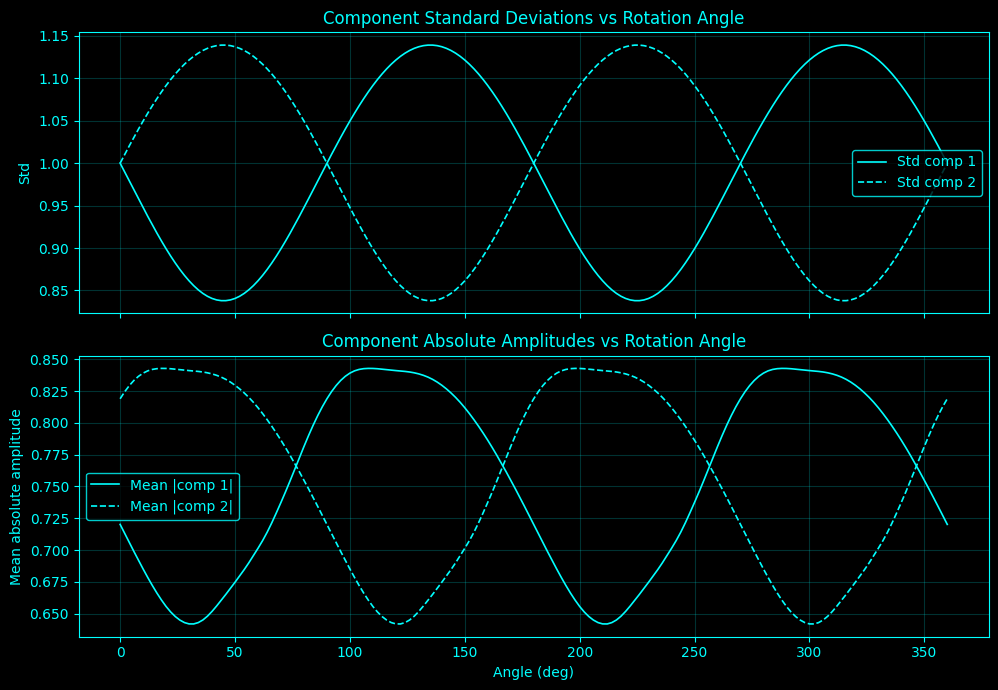


Saved main summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lie_group_so2_channel_pair_analysis/lie_group_so2_main_rotation_summary.csv
Saved angle sweep CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lie_group_so2_channel_pair_analysis/lie_group_so2_angle_sweep.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/lie_group_so2_channel_pair_analysis/lie_group_so2_results.npz
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/lie_group_so2_channel_pair_analysis/lie_group_so2_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/lie_group_so2_channel_pair_analysis/plots


In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "lie_group_so2_channel_pair_analysis")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate

start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Channel pair for the SO(2) action
channel_pair = ("Fp1", "Fp2")

# Main rotation angle for direct visualization
theta_main_deg = 45.0

# Sweep of angles to study invariants
n_theta = 181
theta_grid = np.linspace(0.0, 2.0 * np.pi, n_theta)

ACCENT = "cyan"
BG = "black"
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_3d_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.zaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)
    try:
        ax.xaxis.pane.set_facecolor((0, 0, 0, 1))
        ax.yaxis.pane.set_facecolor((0, 0, 0, 1))
        ax.zaxis.pane.set_facecolor((0, 0, 0, 1))
        ax.xaxis.pane.set_edgecolor(ACCENT)
        ax.yaxis.pane.set_edgecolor(ACCENT)
        ax.zaxis.pane.set_edgecolor(ACCENT)
    except Exception:
        pass

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def zscore_by_channel(x):
    mu = np.mean(x, axis=0, keepdims=True)
    sd = np.std(x, axis=0, keepdims=True)
    return (x - mu) / (sd + eps)

def rotation_matrix(theta):
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([[c, -s], [s, c]], dtype=float)

def so2_transform(X, theta):
    """
    X shape: (time, 2)
    """
    R = rotation_matrix(theta)
    return X @ R.T

def pair_covariance(X):
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    return 0.5 * (C + C.T)

def pair_energy(X):
    return np.sum(X**2, axis=1)

def principal_orientation_deg(C):
    w, V = np.linalg.eigh(C)
    idx = np.argmax(w)
    v = V[:, idx]
    ang = np.degrees(np.arctan2(v[1], v[0]))
    return float(ang)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]
EEG_segment = zscore_by_channel(EEG_segment)

time_sec = start_time + np.arange(EEG_segment.shape[0]) * dt

ch1, ch2 = channel_pair
if ch1 not in eeg_channel_names or ch2 not in eeg_channel_names:
    raise ValueError(f"Channel pair {channel_pair} not found.")

idx1 = eeg_channel_names.index(ch1)
idx2 = eeg_channel_names.index(ch2)

X = EEG_segment[:, [idx1, idx2]]  # (time, 2)
theta_main = np.deg2rad(theta_main_deg)
Y = so2_transform(X, theta_main)

print(f"Loaded EEG segment shape: {EEG_segment.shape}")
print(f"Using channel pair: {ch1}, {ch2}")
print(f"Main rotation angle: {theta_main_deg:.2f} deg")

# -------------------------------------------------------
# MAIN GEOMETRIC QUANTITIES
# -------------------------------------------------------
C_X = pair_covariance(X)
C_Y = pair_covariance(Y)

eig_X = np.linalg.eigvalsh(C_X)
eig_Y = np.linalg.eigvalsh(C_Y)

energy_X = pair_energy(X)
energy_Y = pair_energy(Y)

radius_diff = np.abs(np.sqrt(energy_X) - np.sqrt(energy_Y))
energy_diff = np.abs(energy_X - energy_Y)

base_summary = {
    "channel_1": ch1,
    "channel_2": ch2,
    "theta_main_deg": float(theta_main_deg),
    "cov_trace_original": float(np.trace(C_X)),
    "cov_trace_rotated": float(np.trace(C_Y)),
    "cov_det_original": float(np.linalg.det(C_X)),
    "cov_det_rotated": float(np.linalg.det(C_Y)),
    "eigval1_original": float(eig_X[0]),
    "eigval2_original": float(eig_X[1]),
    "eigval1_rotated": float(eig_Y[0]),
    "eigval2_rotated": float(eig_Y[1]),
    "max_pointwise_energy_difference": float(np.max(energy_diff)),
    "mean_pointwise_energy_difference": float(np.mean(energy_diff)),
    "max_pointwise_radius_difference": float(np.max(radius_diff)),
    "mean_pointwise_radius_difference": float(np.mean(radius_diff)),
    "principal_orientation_original_deg": principal_orientation_deg(C_X),
    "principal_orientation_rotated_deg": principal_orientation_deg(C_Y),
}

# -------------------------------------------------------
# SWEEP ANGLE: INVARIANT / COVARIANT ANALYSIS
# -------------------------------------------------------
theta_rows = []

for theta in theta_grid:
    Z = so2_transform(X, theta)
    C = pair_covariance(Z)
    eig = np.linalg.eigvalsh(C)
    E = pair_energy(Z)

    theta_rows.append({
        "theta_rad": float(theta),
        "theta_deg": float(np.degrees(theta)),
        "cov_trace": float(np.trace(C)),
        "cov_det": float(np.linalg.det(C)),
        "eigval_small": float(eig[0]),
        "eigval_large": float(eig[1]),
        "principal_orientation_deg": principal_orientation_deg(C),
        "mean_energy": float(np.mean(E)),
        "mean_radius": float(np.mean(np.sqrt(E))),
        "mean_abs_amp_channel1": float(np.mean(np.abs(Z[:, 0]))),
        "mean_abs_amp_channel2": float(np.mean(np.abs(Z[:, 1]))),
        "std_channel1": float(np.std(Z[:, 0])),
        "std_channel2": float(np.std(Z[:, 1])),
    })

theta_df = pd.DataFrame(theta_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
summary_txt = os.path.join(out_dir, "lie_group_so2_summary.txt")
theta_csv = os.path.join(out_dir, "lie_group_so2_angle_sweep.csv")
base_csv = os.path.join(out_dir, "lie_group_so2_main_rotation_summary.csv")
npz_path = os.path.join(out_dir, "lie_group_so2_results.npz")

pd.DataFrame([base_summary]).to_csv(base_csv, index=False)
theta_df.to_csv(theta_csv, index=False)

np.savez_compressed(
    npz_path,
    time_sec=time_sec,
    X=X,
    Y=Y,
    C_X=C_X,
    C_Y=C_Y,
    theta_main_deg=theta_main_deg,
    theta_grid=theta_grid,
    eeg_channel_pair=np.array([ch1, ch2], dtype=object),
)

with open(summary_txt, "w") as f:
    f.write("SO(2) Lie-Group Rotation Analysis of EEG Channel Pairs\n")
    f.write("=====================================================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Channel pair: {ch1}, {ch2}\n")
    f.write(f"Main rotation angle: {theta_main_deg:.6f} deg\n\n")
    f.write("Main-rotation invariants and covariants:\n")
    for k, v in base_summary.items():
        f.write(f"  {k}: {v}\n")

# -------------------------------------------------------
# PLOT 1: ORIGINAL VS ROTATED TIME SERIES
# -------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(13, 7), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(time_sec, X[:, 0], color=ACCENT, alpha=0.9, linewidth=1.0, label=ch1)
ax1.plot(time_sec, X[:, 1], color=ACCENT, alpha=0.55, linewidth=1.0, linestyle="--", label=ch2)
ax1.set_title(f"Original Pair Time Series: {ch1}, {ch2}")
ax1.set_ylabel("Amplitude")
ax1.legend()

ax2.plot(time_sec, Y[:, 0], color=ACCENT, alpha=0.9, linewidth=1.0, label="Rotated component 1")
ax2.plot(time_sec, Y[:, 1], color=ACCENT, alpha=0.55, linewidth=1.0, linestyle="--", label="Rotated component 2")
ax2.set_title(f"SO(2)-Rotated Pair Time Series ({theta_main_deg:.1f}°)")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Amplitude")
ax2.legend()

plot1_path = os.path.join(plots_dir, "original_vs_rotated_timeseries.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: CHANNEL-PAIR TRAJECTORY IN 2D PLANE
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=BG)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(X[:, 0], X[:, 1], color=ACCENT, linewidth=0.8, alpha=0.8)
ax1.set_title(f"Original Pair Trajectory: ({ch1}, {ch2})")
ax1.set_xlabel(ch1)
ax1.set_ylabel(ch2)

ax2.plot(Y[:, 0], Y[:, 1], color=ACCENT, linewidth=0.8, alpha=0.8)
ax2.set_title(f"Rotated Pair Trajectory: {theta_main_deg:.1f}°")
ax2.set_xlabel("Rotated component 1")
ax2.set_ylabel("Rotated component 2")

plot2_path = os.path.join(plots_dir, "pair_plane_trajectory_original_vs_rotated.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: 3D TIME-PAIR TRAJECTORY
# -------------------------------------------------------
fig = plt.figure(figsize=(10, 7), facecolor=BG)
ax = fig.add_subplot(111, projection="3d")
style_3d_ax(ax)

ax.plot(time_sec, Y[:, 0], Y[:, 1], color=ACCENT, linewidth=0.7, alpha=0.9)
ax.set_title(f"3D Time-Pair Trajectory After SO(2) Rotation ({theta_main_deg:.1f}°)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Rotated component 1")
ax.set_zlabel("Rotated component 2")

plot3_path = os.path.join(plots_dir, "time_pair_trajectory_3d_rotated.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: INVARIANTS ACROSS ROTATION ANGLE
# -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), facecolor=BG)
for ax in axes.ravel():
    style_ax(ax)

axes[0, 0].plot(theta_df["theta_deg"], theta_df["cov_trace"], color=ACCENT, linewidth=1.2)
axes[0, 0].set_title("Covariance Trace vs Rotation Angle")
axes[0, 0].set_xlabel("Angle (deg)")
axes[0, 0].set_ylabel("Trace")

axes[0, 1].plot(theta_df["theta_deg"], theta_df["cov_det"], color=ACCENT, linewidth=1.2)
axes[0, 1].set_title("Covariance Determinant vs Rotation Angle")
axes[0, 1].set_xlabel("Angle (deg)")
axes[0, 1].set_ylabel("Determinant")

axes[1, 0].plot(theta_df["theta_deg"], theta_df["eigval_small"], color=ACCENT, linewidth=1.2, label="Small eigenvalue")
axes[1, 0].plot(theta_df["theta_deg"], theta_df["eigval_large"], color=ACCENT, linewidth=1.2, linestyle="--", label="Large eigenvalue")
axes[1, 0].set_title("Covariance Eigenvalues vs Rotation Angle")
axes[1, 0].set_xlabel("Angle (deg)")
axes[1, 0].set_ylabel("Eigenvalue")
axes[1, 0].legend()

axes[1, 1].plot(theta_df["theta_deg"], theta_df["principal_orientation_deg"], color=ACCENT, linewidth=1.2)
axes[1, 1].set_title("Principal Orientation vs Rotation Angle")
axes[1, 1].set_xlabel("Angle (deg)")
axes[1, 1].set_ylabel("Orientation (deg)")

plot4_path = os.path.join(plots_dir, "invariants_and_orientation_vs_angle.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: COMPONENT MIXING ACROSS ROTATION ANGLE
# -------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 7), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(theta_df["theta_deg"], theta_df["std_channel1"], color=ACCENT, linewidth=1.2, label="Std comp 1")
ax1.plot(theta_df["theta_deg"], theta_df["std_channel2"], color=ACCENT, linewidth=1.2, linestyle="--", label="Std comp 2")
ax1.set_title("Component Standard Deviations vs Rotation Angle")
ax1.set_ylabel("Std")
ax1.legend()

ax2.plot(theta_df["theta_deg"], theta_df["mean_abs_amp_channel1"], color=ACCENT, linewidth=1.2, label="Mean |comp 1|")
ax2.plot(theta_df["theta_deg"], theta_df["mean_abs_amp_channel2"], color=ACCENT, linewidth=1.2, linestyle="--", label="Mean |comp 2|")
ax2.set_title("Component Absolute Amplitudes vs Rotation Angle")
ax2.set_xlabel("Angle (deg)")
ax2.set_ylabel("Mean absolute amplitude")
ax2.legend()

plot5_path = os.path.join(plots_dir, "component_mixing_vs_angle.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved main summary CSV: {base_csv}")
print(f"Saved angle sweep CSV: {theta_csv}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Hermitian manifold / Kähler-form proxy